In [2]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from PIL import Image
from collections import Counter
import numpy as np

In [3]:
BASE_DIR = r'C:\Users\elent\Downloads\Eye Disease Detection'

DATASET_DIR = os.path.join(BASE_DIR, 'dataset', 'OCT2017')
TRAIN_DIR   = os.path.join(DATASET_DIR, 'train')
VAL_DIR     = os.path.join(DATASET_DIR, 'val')
TEST_DIR    = os.path.join(DATASET_DIR, 'test')

In [4]:
FEATURES_DIR    = os.path.join(BASE_DIR, 'features')
CHECKPOINTS_DIR = os.path.join(BASE_DIR, 'checkpoints')
RESULTS_DIR     = os.path.join(BASE_DIR, 'results')

In [5]:
CLASSES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

In [6]:
for name, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    exists = os.path.exists(path)
    print(f"{name}: {path} --> {'Found' if exists else 'NOT FOUND'}")

Train: C:\Users\elent\Downloads\Eye Disease Detection\dataset\OCT2017\train --> Found
Val: C:\Users\elent\Downloads\Eye Disease Detection\dataset\OCT2017\val --> Found
Test: C:\Users\elent\Downloads\Eye Disease Detection\dataset\OCT2017\test --> Found


In [7]:
def count_images(split_dir, split_name):
    print(f"\n {split_name}")
    print("-" * 35)
    total = 0
    for cls in CLASSES:
        cls_path = os.path.join(split_dir, cls)
        count = len(glob.glob(os.path.join(cls_path, '*.jpeg')))
        total += count
        print(f"  {cls:<10}: {count:>6} images")
    print(f"  {'TOTAL':<10}: {total:>6} images")

count_images(TRAIN_DIR, 'Training Set')
count_images(VAL_DIR,   'Validation Set')
count_images(TEST_DIR,  'Test Set')


 Training Set
-----------------------------------
  CNV       :  37205 images
  DME       :  11348 images
  DRUSEN    :   8616 images
  NORMAL    :  26315 images
  TOTAL     :  83484 images

 Validation Set
-----------------------------------
  CNV       :      8 images
  DME       :      8 images
  DRUSEN    :      8 images
  NORMAL    :      8 images
  TOTAL     :     32 images

 Test Set
-----------------------------------
  CNV       :    242 images
  DME       :    242 images
  DRUSEN    :    242 images
  NORMAL    :    242 images
  TOTAL     :    968 images


In [8]:
import numpy as np
train_counts = {
    'CNV'   : 37205,
    'DME'   : 11348,
    'DRUSEN':  8616,
    'NORMAL': 26315
}

total_train = sum(train_counts.values())
num_classes = len(CLASSES)

print(" Class Weights (for handling imbalance)")
print("-" * 40)

class_weights = {}
for cls, count in train_counts.items():
    weight = total_train / (num_classes * count)
    class_weights[cls] = round(weight, 4)
    print(f"  {cls:<10}: weight = {weight:.4f}  (n={count})")

print(f"\n  Higher weight = model penalized more for missing that class")
print(f"  DRUSEN gets the highest weight because it has the fewest samples")


 Class Weights (for handling imbalance)
----------------------------------------
  CNV       : weight = 0.5610  (n=37205)
  DME       : weight = 1.8392  (n=11348)
  DRUSEN    : weight = 2.4224  (n=8616)
  NORMAL    : weight = 0.7931  (n=26315)

  Higher weight = model penalized more for missing that class
  DRUSEN gets the highest weight because it has the fewest samples


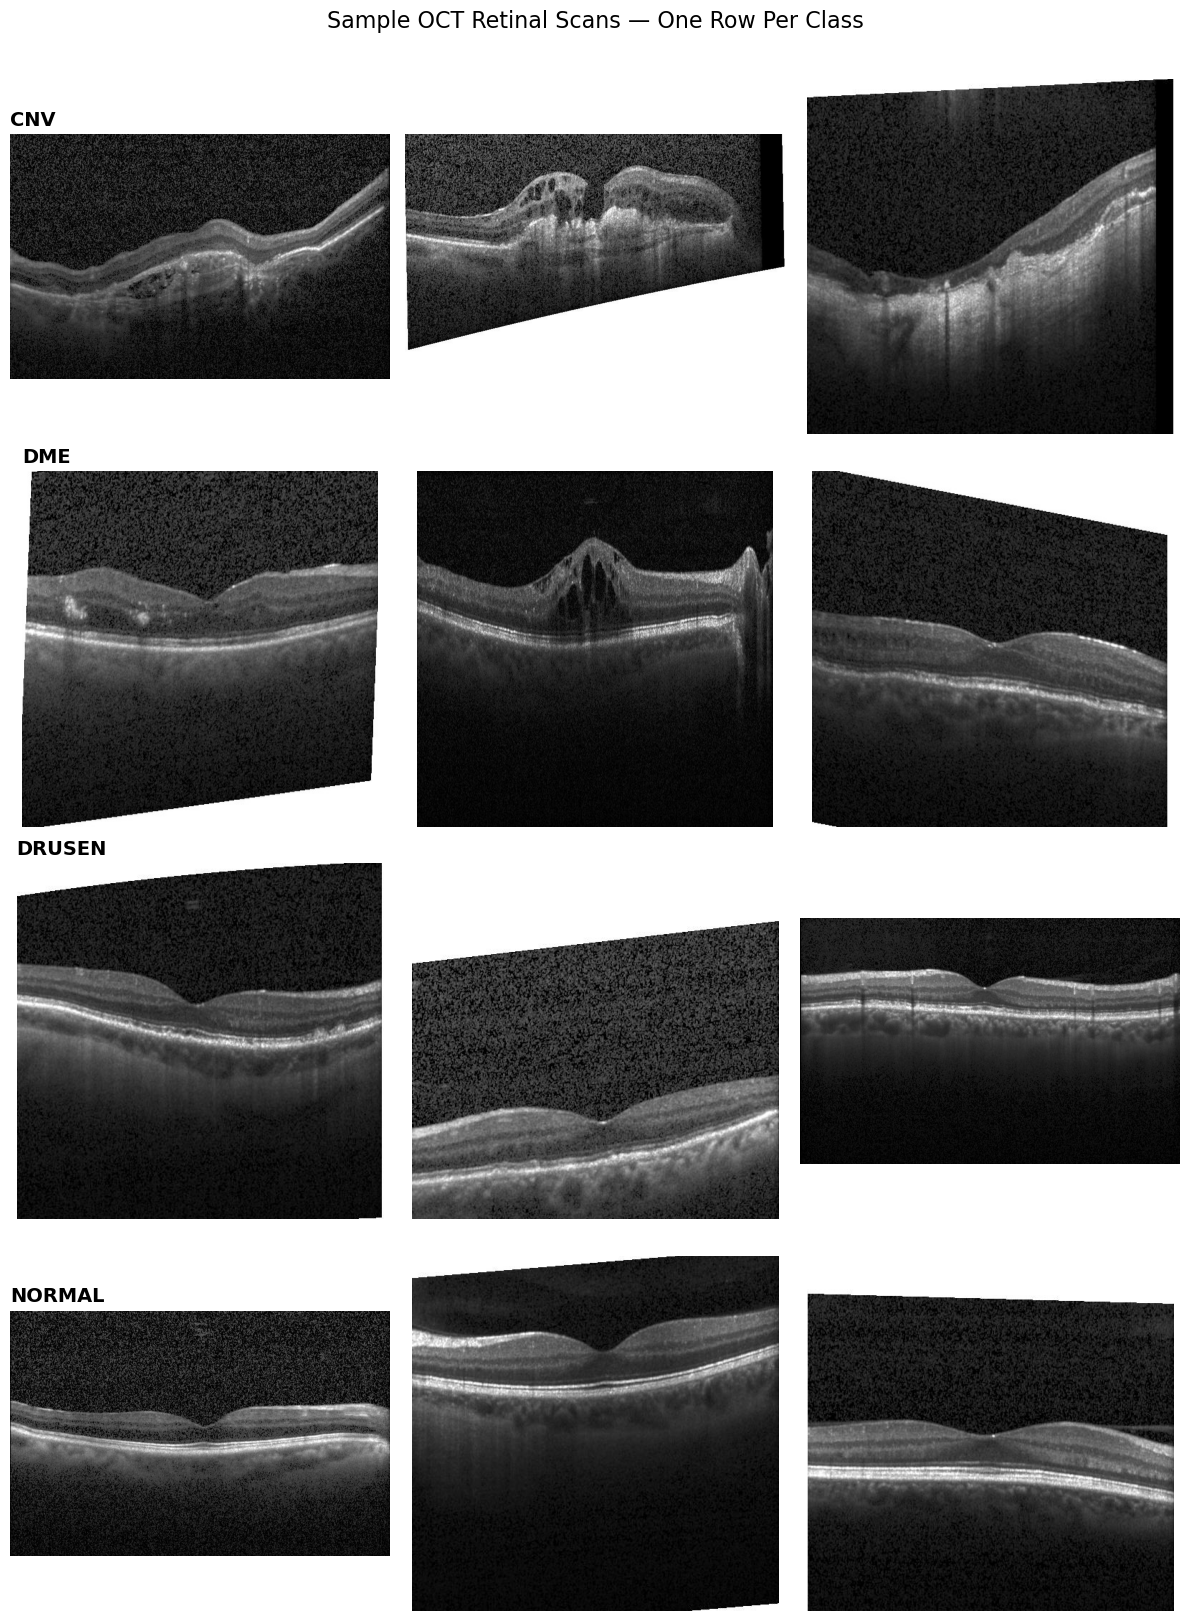

 Saved to results folder


In [9]:
def show_sample_images(split_dir, samples_per_class=3):
    fig, axes = plt.subplots(4, samples_per_class, figsize=(samples_per_class * 4, 16))
    fig.suptitle('Sample OCT Retinal Scans — One Row Per Class', fontsize=16, y=1.01)

    for row, cls in enumerate(CLASSES):
        cls_path = os.path.join(split_dir, cls)
        images = glob.glob(os.path.join(cls_path, '*.jpeg'))
        if not images:
            images = glob.glob(os.path.join(cls_path, '*.jpg'))

        sampled = random.sample(images, samples_per_class)

        for col, img_path in enumerate(sampled):
            img = mpimg.imread(img_path)
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_title(cls, fontsize=14, fontweight='bold', loc='left')

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(" Saved to results folder")

show_sample_images(TRAIN_DIR)

In [10]:
def check_image_sizes(split_dir, split_name, sample_size=20):
    print(f"\n Image Size Distribution — {split_name}")

    sizes = []
    for cls in CLASSES:
        cls_path = os.path.join(split_dir, cls)
        images = glob.glob(os.path.join(cls_path, '*.jpeg'))
        if not images:
            images = glob.glob(os.path.join(cls_path, '*.jpg'))

        sampled = random.sample(images, min(sample_size, len(images)))
        for img_path in sampled:
            try:
                with Image.open(img_path) as img:
                    sizes.append(img.size)
            except:
                pass

    size_counts = Counter(sizes)
    print(f"  Total images sampled : {len(sizes)}")
    print(f"  Unique sizes found   : {len(size_counts)}")
    print(f"\n  Top 5 most common sizes (width x height):")
    for size, count in size_counts.most_common(5):
        print(f"    {str(size):<20}: {count} images")

check_image_sizes(TRAIN_DIR, 'Training Set')


 Image Size Distribution — Training Set
  Total images sampled : 80
  Unique sizes found   : 4

  Top 5 most common sizes (width x height):
    (512, 496)          : 33 images
    (512, 512)          : 21 images
    (768, 496)          : 19 images
    (1536, 496)         : 7 images


- Most common is 512×496 — roughly square-ish
- Some are 768×496 and 1536×496 — wider, panoramic scans
- ResNet50 needs exactly 224×224 so all of these will get resized

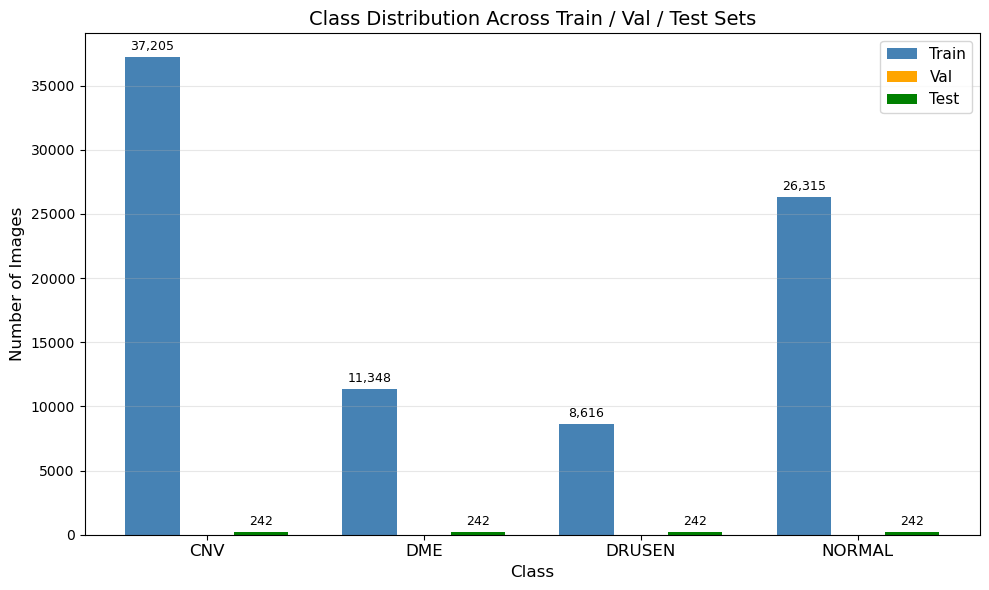

 Saved to results folder


In [11]:
train_counts = [37205, 11348, 8616, 26315]
val_counts   = [8, 8, 8, 8]
test_counts  = [242, 242, 242, 242]

x = np.arange(len(CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, train_counts, width, label='Train', color='steelblue')
bars2 = ax.bar(x,         val_counts,   width, label='Val',   color='orange')
bars3 = ax.bar(x + width, test_counts,  width, label='Test',  color='green')
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution Across Train / Val / Test Sets', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to results folder")

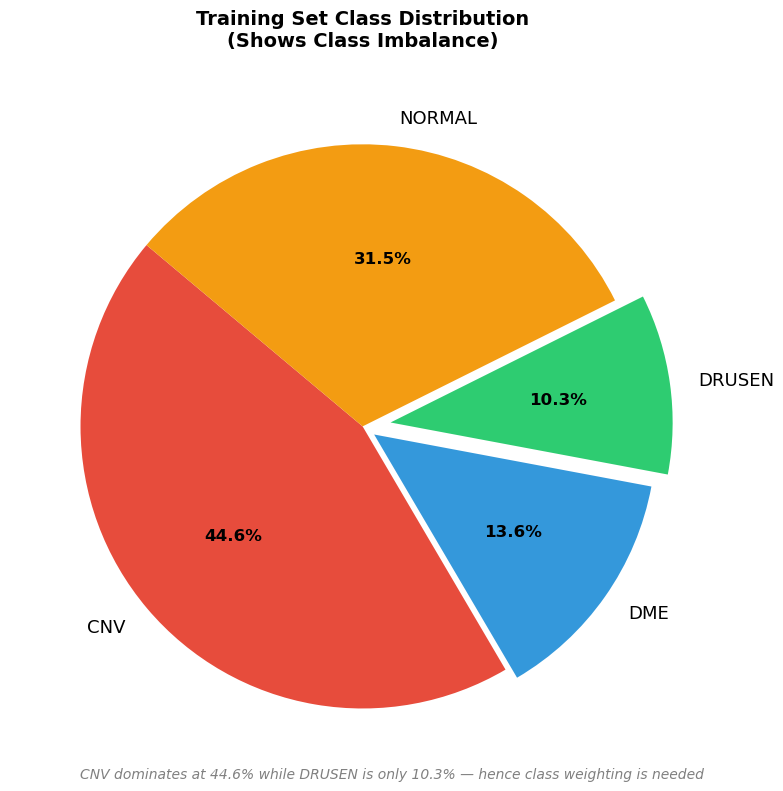

 Saved to results folder


In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
explode = (0, 0.05, 0.1, 0)

wedges, texts, autotexts = ax.pie(
    train_counts,
    labels=CLASSES,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 13}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.set_title('Training Set Class Distribution\n(Shows Class Imbalance)',
             fontsize=14, fontweight='bold', pad=20)

fig.text(0.5, 0.02,
         'CNV dominates at 44.6% while DRUSEN is only 10.3% — hence class weighting is needed',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution_pie.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to results folder")

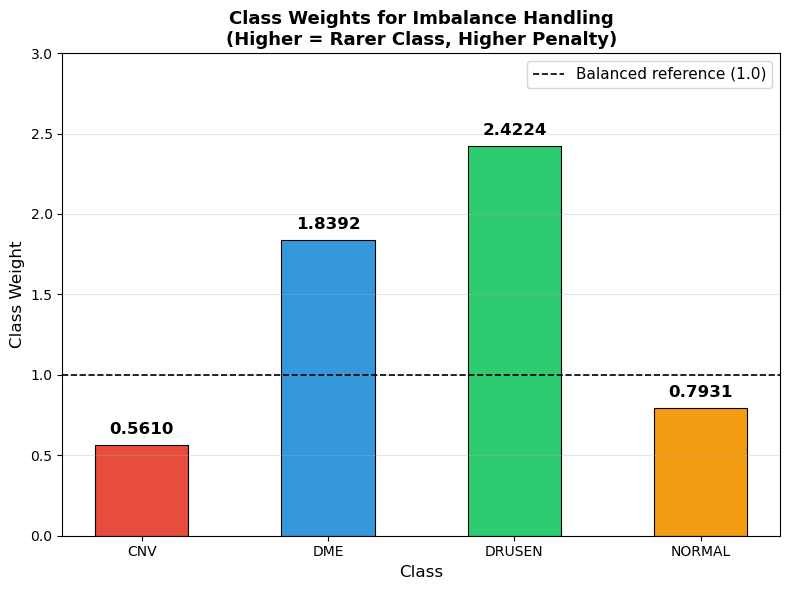

 Saved to results folder


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
weights = [0.5610, 1.8392, 2.4224, 0.7931]

bars = ax.bar(CLASSES, weights, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

for bar, weight in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{weight:.4f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2, label='Balanced reference (1.0)')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Class Weight', fontsize=12)
ax.set_title('Class Weights for Imbalance Handling\n(Higher = Rarer Class, Higher Penalty)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 3.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_weights.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to results folder")

The dashed line at 1.0 is a nice reference point — bars above it are underrepresented classes, bars below are overrepresented. DRUSEN towers above everything at 2.42.

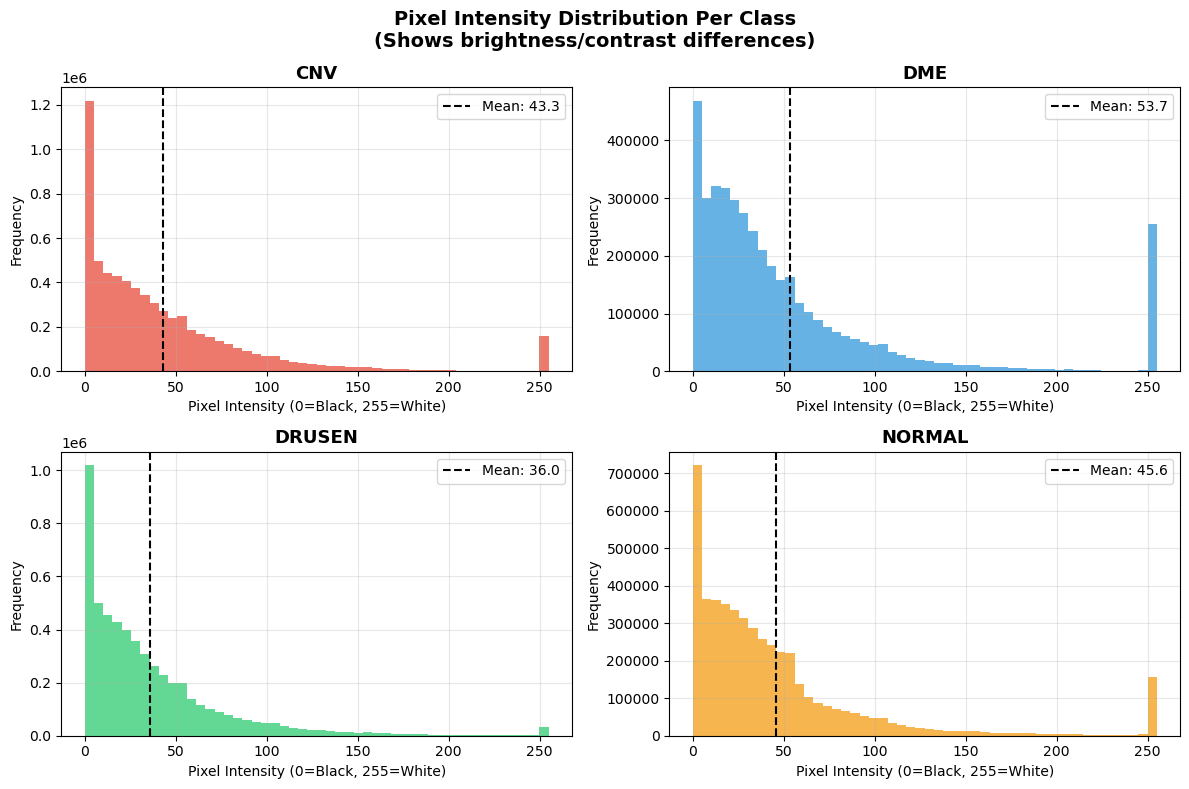

 Saved to results folder


In [14]:
def get_pixel_intensities(split_dir, cls, sample_size=15):
    cls_path = os.path.join(split_dir, cls)
    images = glob.glob(os.path.join(cls_path, '*.jpeg'))
    if not images:
        images = glob.glob(os.path.join(cls_path, '*.jpg'))

    sampled = random.sample(images, min(sample_size, len(images)))
    intensities = []
    for img_path in sampled:
        try:
            with Image.open(img_path) as img:
                img_gray = img.convert('L')
                pixels = np.array(img_gray).flatten()
                intensities.extend(pixels.tolist())
        except:
            pass
    return intensities

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig.suptitle('Pixel Intensity Distribution Per Class\n(Shows brightness/contrast differences)',
             fontsize=14, fontweight='bold')

for idx, (cls, color) in enumerate(zip(CLASSES, colors)):
    ax = axes[idx // 2, idx % 2]
    intensities = get_pixel_intensities(TRAIN_DIR, cls)

    ax.hist(intensities, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(np.mean(intensities), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {np.mean(intensities):.1f}')

    ax.set_title(cls, fontsize=13, fontweight='bold')
    ax.set_xlabel('Pixel Intensity (0=Black, 255=White)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'pixel_intensity.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to results folder")

Key Observations:

- All four classes are heavily left-skewed — OCT scans are mostly dark (black background) with bright retinal tissue in the center, which is exactly what we'd expect
- The spike at 255 in CNV, DME, and DRUSEN represents the bright fluid/deposit regions — this is actually clinically meaningful, those bright spots are the disease markers
- NORMAL has the lowest mean (40.9) and the smallest 255-spike — healthy retinas have less abnormal bright tissue
- CNV, DME and DRUSEN all have means around 49-53, slightly brighter than NORMAL due to fluid and deposits

In [ ]:
def compute_mean_image(split_dir, cls, sample_size=50):
    cls_path = os.path.join(split_dir, cls)
    images = glob.glob(os.path.join(cls_path, '*.jpeg'))
    if not images:
        images = glob.glob(os.path.join(cls_path, '*.jpg'))

    sampled = random.sample(images, min(sample_size, len(images)))
    arrays = []
    for img_path in sampled:
        try:
            with Image.open(img_path) as img:
                img_resized = img.convert('L').resize((224, 224))
                arrays.append(np.array(img_resized))
        except:
            pass
    return np.mean(arrays, axis=0).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig.suptitle('Mean Image Per Class\n(Average of 50 images — shows typical scan structure per disease)',
             fontsize=13, fontweight='bold')

for idx, (cls, color) in enumerate(zip(CLASSES, colors)):
    mean_img = compute_mean_image(TRAIN_DIR, cls)
    axes[idx].imshow(mean_img, cmap='gray')
    axes[idx].set_title(cls, fontsize=13, fontweight='bold', color=color)
    axes[idx].axis('off')
    axes[idx].text(0.5, -0.05, f'Mean brightness: {mean_img.mean():.1f}',
                   transform=axes[idx].transAxes,
                   ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'mean_images.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to results folder")

In [ ]:
def get_samples(split_dir, cls, n=6):
    cls_path = os.path.join(split_dir, cls)
    images = glob.glob(os.path.join(cls_path, '*.jpeg'))
    if not images:
        images = glob.glob(os.path.join(cls_path, '*.jpg'))
    if not images:
        images = glob.glob(os.path.join(cls_path, '*.JPEG'))
    return random.sample(images, min(n, len(images)))

print(" get_samples defined")

In [ ]:
cnv_samples = get_samples(TRAIN_DIR, 'CNV', n=4)
dme_samples = get_samples(TRAIN_DIR, 'DME', n=4)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

fig.suptitle('CNV vs DME — Why These Two Are Hard to Distinguish\n'
             'Both show fluid but in different locations and patterns',
             fontsize=13, fontweight='bold', y=1.02)

for col, img_path in enumerate(cnv_samples):
    img = mpimg.imread(img_path)
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].axis('off')
    axes[0, col].set_title(f'CNV #{col+1}\nFluid above/below retinal layer',
                            fontsize=9, color='#e74c3c', fontweight='bold', pad=8)

for col, img_path in enumerate(dme_samples):
    img = mpimg.imread(img_path)
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].axis('off')
    axes[1, col].set_title(f'DME #{col+1}\nCyst-like fluid in macula center',
                            fontsize=9, color='#3498db', fontweight='bold', pad=8)

fig.text(0.005, 0.73, 'CNV', fontsize=15, fontweight='bold',
         color='#e74c3c', va='center', rotation=90)
fig.text(0.005, 0.27, 'DME', fontsize=15, fontweight='bold',
         color='#3498db', va='center', rotation=90)

plt.subplots_adjust(left=0.03, hspace=0.35)
plt.savefig(os.path.join(RESULTS_DIR, 'cnv_vs_dme.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to results folder")